# Energy Consumption Forecasting — Exploratory Data Analysis

This notebook explores the PJM East hourly electricity consumption dataset (2002–2018).
We examine the time series structure, seasonal patterns, and the distribution of the
target variable `PJME_MW` before any feature engineering.

## 1. Imports & Load Data

We load the raw hourly dataset and parse the `Datetime` column so that pandas
can work with it as a proper time index.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

df = pd.read_csv('data/PJME_hourly.csv', parse_dates=['Datetime'])
print('Loaded:', df.shape)
df.head()

Loaded: (145366, 2)


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


## 2. Dataset Overview

A quick look at shape, data types, basic statistics, duplicates, and missing values
gives us a sense of data quality before we dive into visualisations.

In [2]:
print('Shape:', df.shape)
print('\nColumn dtypes:')
print(df.dtypes)
print('\nDate range:', df['Datetime'].min(), '→', df['Datetime'].max())
print('\nDuplicates:', df.duplicated().sum())
print('Missing values:')
print(df.isnull().sum())

Shape: (145366, 2)

Column dtypes:
Datetime    datetime64[ns]
PJME_MW            float64
dtype: object

Date range: 2002-01-01 01:00:00 → 2018-08-03 00:00:00



Duplicates: 0
Missing values:
Datetime    0
PJME_MW     0
dtype: int64


In [3]:
df['PJME_MW'].describe().round(2)

count    145366.00
mean      32080.22
std        6464.01
min       14544.00
25%       27573.00
50%       31421.00
75%       35650.00
max       62009.00
Name: PJME_MW, dtype: float64

## 3. Consumption Over Time — Full Series

Plotting the entire 16-year series reveals long-run trends, seasonal cycles
(annual peaks in summer and winter), and any obvious anomalies or data gaps.

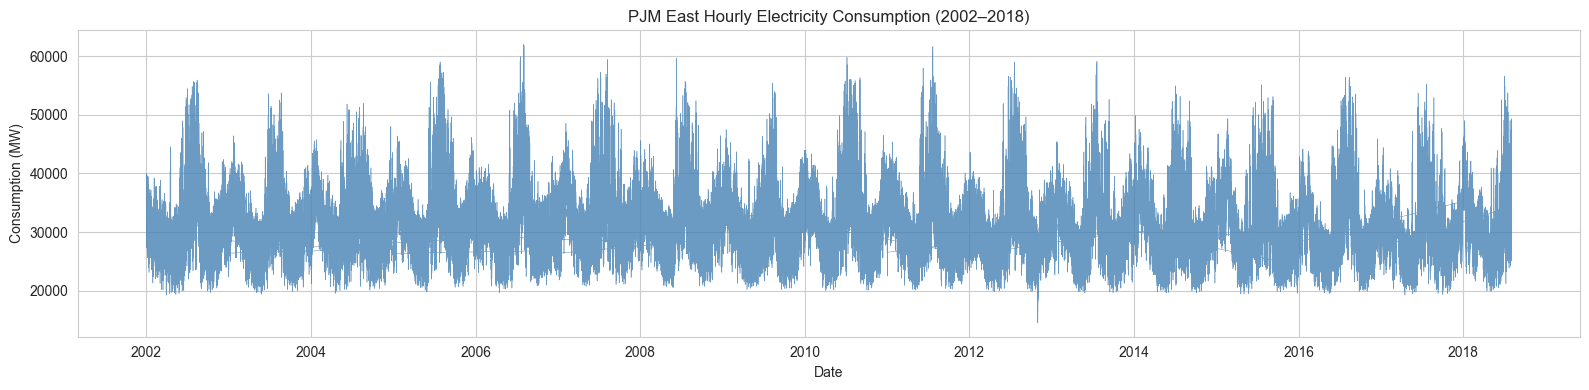

In [4]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df['Datetime'], df['PJME_MW'], linewidth=0.4, color='steelblue', alpha=0.8)
ax.set_title('PJM East Hourly Electricity Consumption (2002–2018)')
ax.set_xlabel('Date')
ax.set_ylabel('Consumption (MW)')
plt.tight_layout()
plt.show()

## 4. Target Variable Distribution

A histogram and box plot of `PJME_MW` show the overall spread, central tendency,
and any extreme outliers in the consumption data.

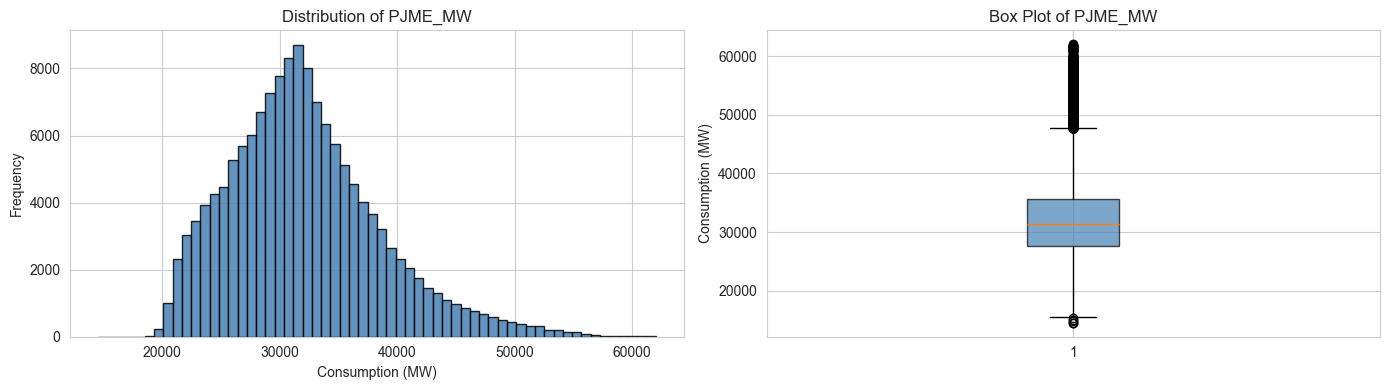

Skewness: 0.739


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['PJME_MW'], bins=60, color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_title('Distribution of PJME_MW')
axes[0].set_xlabel('Consumption (MW)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['PJME_MW'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Box Plot of PJME_MW')
axes[1].set_ylabel('Consumption (MW)')

plt.tight_layout()
plt.show()
print(f"Skewness: {df['PJME_MW'].skew():.3f}")

## 5. Seasonality Analysis

Energy consumption is strongly shaped by time-of-day, day-of-week, and month-of-year.
We extract these calendar components and plot the mean consumption for each level
to understand the key seasonal drivers.

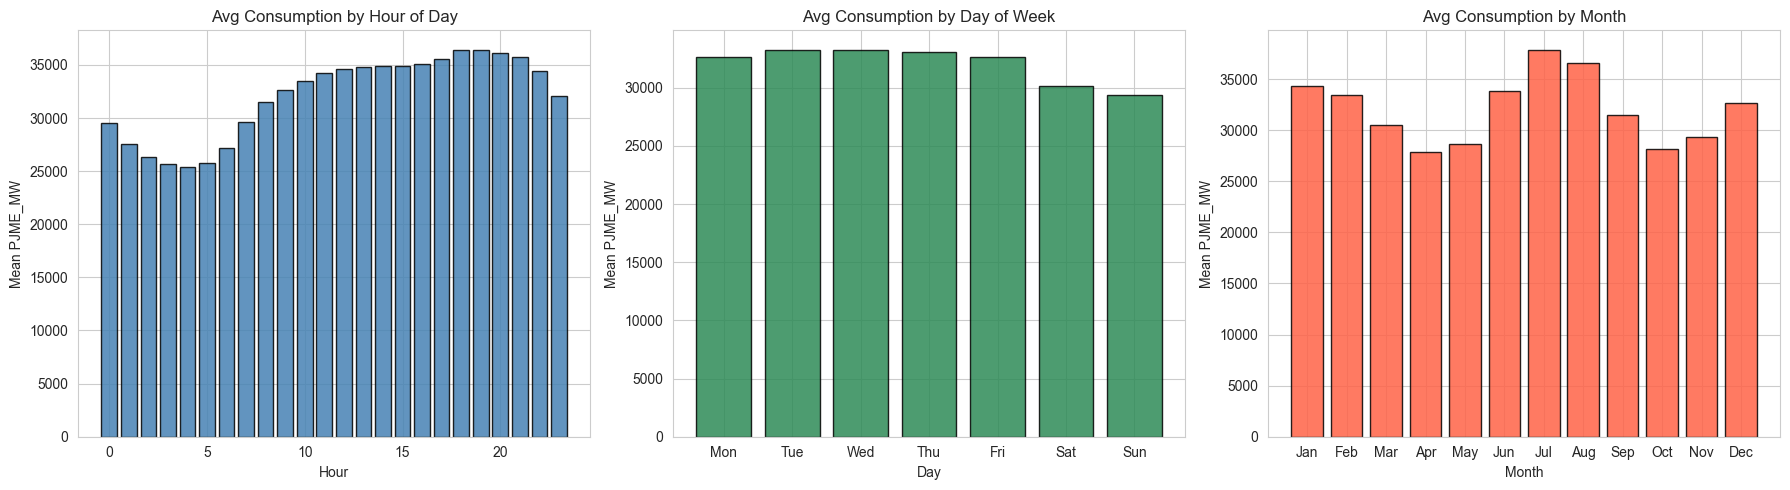

In [6]:
df['hour']      = df['Datetime'].dt.hour
df['dayofweek'] = df['Datetime'].dt.dayofweek
df['month']     = df['Datetime'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hour of day
hourly = df.groupby('hour')['PJME_MW'].mean()
axes[0].bar(hourly.index, hourly.values, color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_title('Avg Consumption by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Mean PJME_MW')

# Day of week
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow = df.groupby('dayofweek')['PJME_MW'].mean()
axes[1].bar(dow_labels, dow.values, color='seagreen', edgecolor='black', alpha=0.85)
axes[1].set_title('Avg Consumption by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Mean PJME_MW')

# Month
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('month')['PJME_MW'].mean()
axes[2].bar(month_labels, monthly.values, color='tomato', edgecolor='black', alpha=0.85)
axes[2].set_title('Avg Consumption by Month')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Mean PJME_MW')

plt.tight_layout()
plt.show()

## 6. Yearly Trend

Aggregating to annual mean consumption reveals any long-run growth or decline
in the PJM East region's electricity demand over the 16-year window.

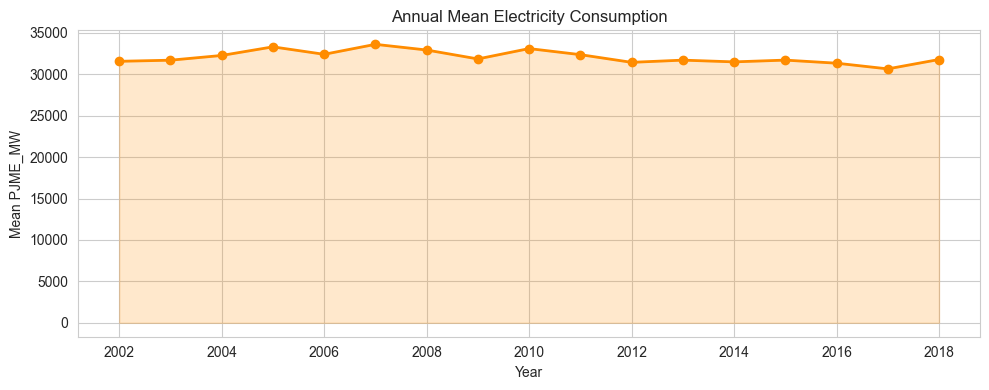

In [7]:
df['year'] = df['Datetime'].dt.year
yearly = df.groupby('year')['PJME_MW'].mean()

plt.figure(figsize=(10, 4))
plt.plot(yearly.index, yearly.values, marker='o', color='darkorange', linewidth=2)
plt.fill_between(yearly.index, yearly.values, alpha=0.2, color='darkorange')
plt.title('Annual Mean Electricity Consumption')
plt.xlabel('Year')
plt.ylabel('Mean PJME_MW')
plt.tight_layout()
plt.show()

## 7. Sample Week — Zoomed-In View

A single week of data shows the characteristic daily double-peak pattern
(morning ramp-up and afternoon/evening peak) as well as the weekend dip.

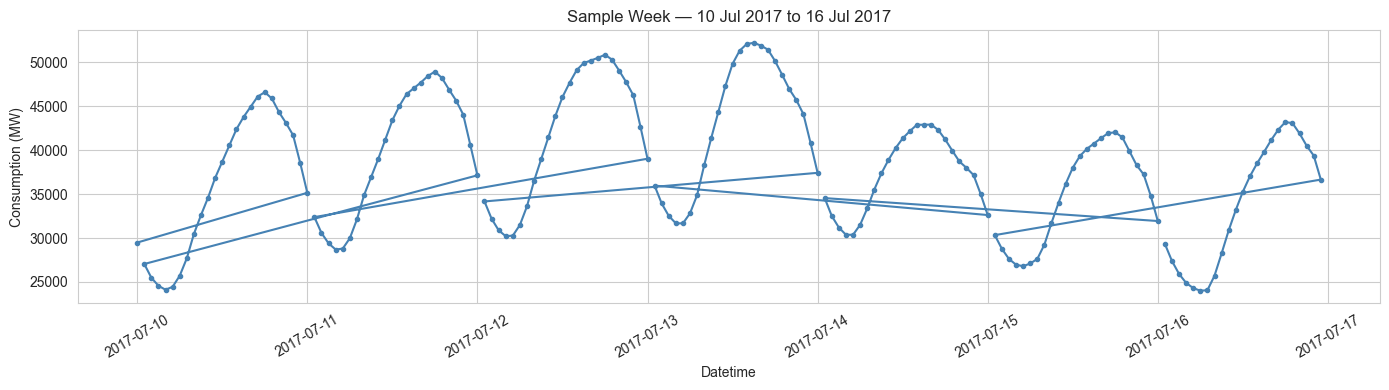

In [8]:
sample_week = df[(df['Datetime'] >= '2017-07-10') & (df['Datetime'] < '2017-07-17')]

plt.figure(figsize=(14, 4))
plt.plot(sample_week['Datetime'], sample_week['PJME_MW'],
         marker='o', markersize=3, color='steelblue', linewidth=1.5)
plt.title('Sample Week — 10 Jul 2017 to 16 Jul 2017')
plt.xlabel('Datetime')
plt.ylabel('Consumption (MW)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 8. Summary of Key Findings

The table below captures the most important observations from the EDA.
These will guide feature engineering choices in notebook 02.

In [9]:
summary = pd.DataFrame({
    'Finding': [
        'Dataset size',
        'Date range',
        'Target mean',
        'Target std',
        'Target min / max',
        'Missing values',
        'Duplicate rows',
        'Peak hour',
        'Lowest-demand hour',
        'Peak month',
        'Lowest-demand month',
        'Weekend effect',
        'Long-run trend',
    ],
    'Value': [
        f"{df.shape[0]:,} rows × {df.shape[1]} cols",
        f"{df['Datetime'].min().date()} → {df['Datetime'].max().date()}",
        f"{df['PJME_MW'].mean():,.0f} MW",
        f"{df['PJME_MW'].std():,.0f} MW",
        f"{df['PJME_MW'].min():,.0f} / {df['PJME_MW'].max():,.0f} MW",
        str(df.isnull().sum().sum()),
        str(df.duplicated().sum()),
        f"Hour {hourly.idxmax()} ({hourly.max():,.0f} MW avg)",
        f"Hour {hourly.idxmin()} ({hourly.min():,.0f} MW avg)",
        f"{month_labels[monthly.idxmax()-1]} ({monthly.max():,.0f} MW avg)",
        f"{month_labels[monthly.idxmin()-1]} ({monthly.min():,.0f} MW avg)",
        f"Weekdays ~{dow[:5].mean():,.0f} MW vs weekends ~{dow[5:].mean():,.0f} MW",
        'Slight decline from ~37k MW (2004) to ~34k MW (2017)',
    ]
})
summary

,Finding,Value
0,Dataset size,"145,366 rows × 6 cols"
1,Date range,2002-01-01 → 2018-08-03
2,Target mean,"32,080 MW"
3,Target std,"6,464 MW"
4,Target min / max,"14,544 / 62,009 MW"
5,Missing values,0
6,Duplicate rows,0
7,Peak hour,"Hour 19 (36,427 MW avg)"
8,Lowest-demand hour,"Hour 4 (25,415 MW avg)"
9,Peak month,"Jul (37,882 MW avg)"
